In [26]:

import pandas as pd
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\training\.venv\Scripts\Datasets\Health_Insurance.csv")
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [28]:
df.rename(columns={
    'age' : "Age",
    "sex" : "Gender"
},inplace=True)

In [29]:

df.columns

Index(['Age', 'Gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [30]:
df.isnull().sum()

Age         0
Gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [31]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [32]:
df.sort_values("Age").head(15)

,Age,Gender,bmi,children,smoker,region,charges
57,18,male,31.680,2,yes,southeast,34303.167200
31,18,female,26.315,0,no,northeast,2198.189850
1023,18,male,23.320,1,no,southeast,1711.026800
427,18,female,29.165,0,no,northeast,7323.734819
1317,18,male,53.130,0,no,southeast,1163.462700
1315,18,male,28.310,1,no,northeast,11272.331390
1334,18,female,31.920,0,no,northeast,2205.980800
399,18,female,38.170,0,no,southeast,1631.668300
1282,18,female,21.660,0,yes,northeast,14283.459400
1283,18,male,30.030,1,no,southeast,1720.353700


In [33]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print("Q1: ",q1)
print("Q3: ",q3)
print("IQR: ",IQR)
print("Lower: ",lower_limit)
print("Upper: ",upper_limit)
outliers = df[
    (df["Age"]<lower_limit) |
    (df["Age"]>upper_limit)
]
print("\nNumber of Age outliers: ",len(outliers))
print("\nAge outliers:")
print(outliers[["bmi","Age"]].head(20))


Q1:  27.0
Q3:  51.0
IQR:  24.0
Lower:  -9.0
Upper:  87.0

Number of Age outliers:  0

Age outliers:
Empty DataFrame
Columns: [bmi, Age]
Index: []


TypeError: 'str' object is not callable

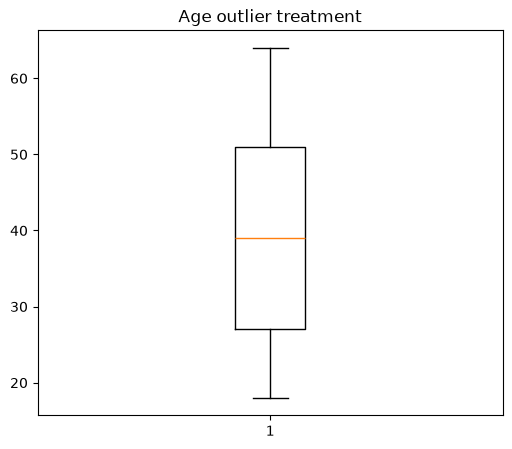

In [34]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.boxplot(df["Age"])
plt.title("Age outlier treatment")
plt.ylabel('Age')
plt.show()

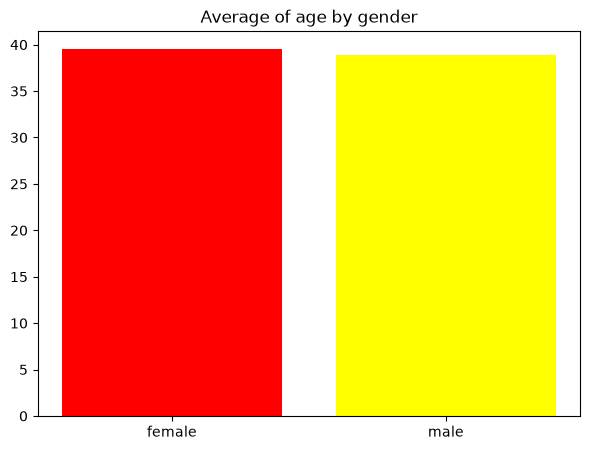

In [ ]:
Age = df.groupby("Gender")['Age'].mean()
plt.figure(figsize=(7,5))
plt.bar(Age.index,Age.values,color=["red","yellow"])
plt.title("Average of age by gender")
plt.xlabel = ("Gender")
plt.ylabel = ("Average age")
plt.show()


Average charges by region:
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


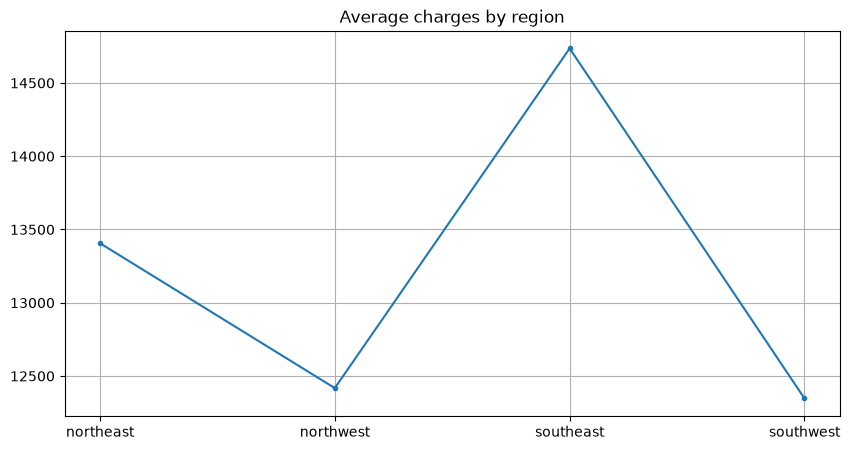

In [ ]:
region_vs_charges = df.groupby("region")["charges"].mean()
print("\nAverage charges by region:")
print(region_vs_charges)
plt.figure(figsize=(10,5))
plt.plot(
    region_vs_charges.index,
    region_vs_charges.values,
    marker="."
)

plt.title("Average charges by region")
plt.xlabel = ("region")
plt.ylabel = ("charges")
plt.grid(True)
plt.show()

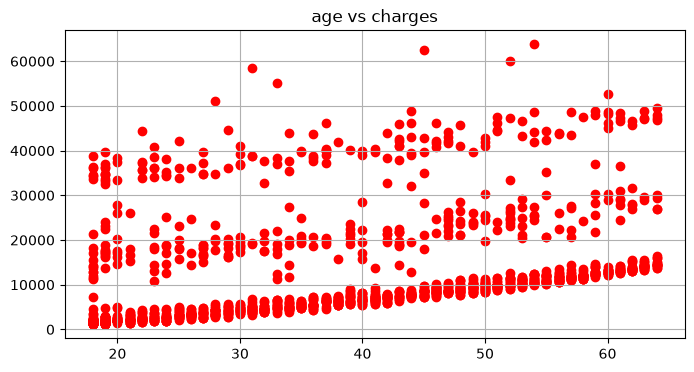

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["Age"], df["charges"], color="red")

plt.title("age vs charges")
plt.xlabel = ("Age")
plt.ylabel = ("charges")
plt.grid(True)

plt.show()

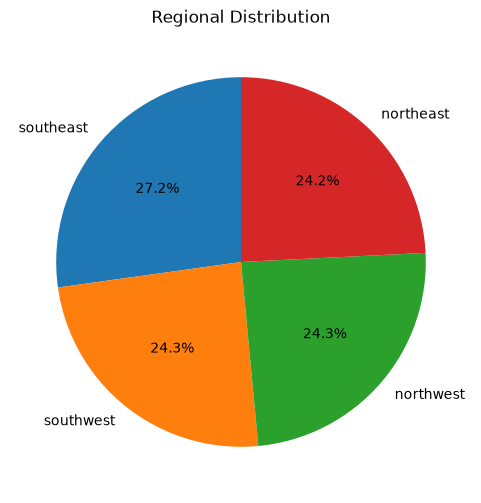

In [ ]:
region = df["region"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(region,
        labels=region.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Regional Distribution")
plt.show()

Correlation

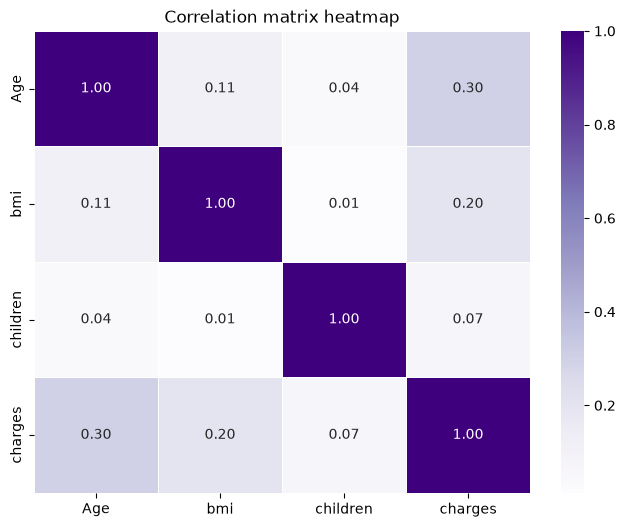

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "Purples",
    fmt = ".2f",
    linewidths = 0.5
)
plt.title("Correlation matrix heatmap")
plt.show()

Feature intution

First 5 Rows:
   Age  Gender     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Last 5 Rows:
      Age  Gender    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0 

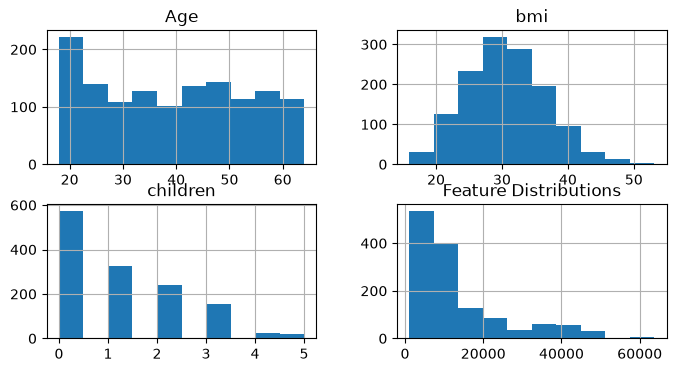

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(8,4))
plt.title("Feature Distributions")
plt.show()